In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime, csv
from matplotlib.colors import LinearSegmentedColormap

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/monitor'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [2]:
def log_to_csv(input_file, output_file):
    headers = [
        "Date", "Time", "gpu", "pwr", "gtemp", "mtemp", "sm", "mem", "enc", "dec", 
        "jpg", "ofa", "mclk", "pclk", "pviol", "tviol", "fb", "bar1", "ccpm", 
        "sbecc", "dbecc", "pci", "rxpci", "txpci"
    ]
    
    with open(input_file, 'r') as infile, open(output_file, 'w', newline='') as outfile:
        writer = csv.writer(outfile, quoting=csv.QUOTE_MINIMAL, escapechar='\\')
        writer.writerow(headers)
        
        for line in infile:
            if line.startswith('#') or not line.strip():
                continue
            
            parts = line.split()
                        # 确保每行数据列数一致（24列）
            if len(parts) == 24:
                writer.writerow(parts)
            else:
                print(f"警告: 跳过不完整的行: {line.strip()}")

if __name__ == "__main__":
    input_log = f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-13b-chat-hf_gpu_monitor_3024_swap_1gpu.log"  # 替换为你的输入日志文件名
    input_log = f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-13b-chat-hf_gpu_monitor_4541_swap_1gpu.log"  # 替换为你的输入日志文件名
    # input_log = f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-13b-chat-hf_gpu_monitor_6069_swap_1gpu.log"  # 替换为你的输入日志文件名
    input_log = f"{DATASET_PATH}/vllm-recompute/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_6069_recompute_4gpu.log"  # 替换为你的输入日志文件名
    # input_log = f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_4541_swap_4gpu.log"  # 替换为你的输入日志文件名
    # input_log = f"{DATASET_PATH}/hcache/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_3024_recompute_4gpu.log"  # 替换为你的输入日志文件名
    # input_log = f"{DATASET_PATH}/ellm/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_3024_recompute_4gpu.log"  # 替换为你的输入日志文件名
    output_csv = input_log.replace('.log', '.csv')  # 输出CSV文件名
    
    # log_to_csv(input_log, output_csv)
    print(f"save file to {output_csv}")

save file to /root/workspace/vllm-dynamic/scripts/dataset/monitor/vllm-recompute/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_6069_recompute_4gpu.csv


In [3]:
def plot_metric_heatmap(csv_files, system_labels, metric, metric_label):
    # 准备数据
    all_data = []
    max_len = 0
    
    for i, csv_file in enumerate(csv_files):
        df = pd.read_csv(csv_file)
        if i < 3:
            df = df[df['gpu'] == 1]  # 只选择第一个GPU的数据
        df = df[df[metric] > 0]
        df = df.iloc[30:1030]  # 截取前1000行
        metric_v = df[metric].values
        if 'pci' in metric:
            metric_v = metric_v / 1024
        all_data.append(metric_v)
        max_len = max(max_len, len(metric_v))
    
    # 确保所有数据长度一致（用NaN填充不足部分）
    data_matrix = np.full((len(all_data), max_len), np.nan)
    for i, data in enumerate(all_data):
        data_matrix[i, :len(data)] = data

    colors = ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]  # 蓝到红的渐变色
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)        
    
    fig, ax = plt.subplots(figsize=(3, 2), dpi=120)
    heatmap = ax.imshow(data_matrix, 
                       aspect='auto', 
                       cmap='viridis',
                        # cmap=cmap,
                       interpolation='nearest')
    # 标注均值
    for i in range(len(system_labels)):
        mean_value = np.nanmean(data_matrix[i])
        print(f"System {system_labels[i]}: {metric} mean value: {mean_value:.2f}")
        # ax.text(800, i, f'avg:{mean_value:.2f}', ha='center', va='center', color='white', fontsize=8)
    ax.set_yticks(np.arange(len(system_labels)))
    ax.set_yticklabels(system_labels)
    ax.set_xlabel('Time (s)')
    ax.set_xlim(0, 1000)
    
    cbar = plt.colorbar(heatmap, ax=ax)
    cbar.set_label(metric_label)
    
    plt.tight_layout(pad=0., w_pad=0., h_pad=0.)
    plt.savefig(f'{PDF_PATH}/e2e_{metric}_heatmap.pdf', bbox_inches='tight')

In [25]:
def plot_metric_density(csv_files, system_labels, metric, metric_label):
    # 准备数据
    all_data = []
    
    for i, csv_file in enumerate(csv_files):
        df = pd.read_csv(csv_file)
        if i < 3:
            df = df[df['gpu'] == 1]  # 只选择第一个GPU的数据
        df = df[df[metric] > 0]
        df = df.iloc[30:1030]  # 截取前1000行
        metric_v = df[metric].values
        if 'pci' in metric:
            metric_v = metric_v / 1024
        
        # 为每个系统创建带标签的DataFrame
        temp_df = pd.DataFrame({metric: metric_v, 'System': system_labels[i]})
        all_data.append(temp_df)
    
    # 合并所有数据
    combined_df = pd.concat(all_data)
    
    # 设置绘图风格
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    for i, label in enumerate(system_labels):
        # 计算核密度估计
        sns.kdeplot(data=combined_df[combined_df['System'] == label], x=metric, 
                    ax=ax, cumulative=False, color=plt.cm.tab20b((4-i)/4), linestyle='-', linewidth=1.5, label=system_labels[i], alpha=0.5, fill=True, zorder=10, clip=(0, 100))
    
    # 添加均值线
    for i, label in enumerate(system_labels):
        mean_value = combined_df[combined_df['System'] == label][metric].mean()
        ax.axvline(mean_value, color=plt.cm.tab20b((4-i)/4), linestyle='--', linewidth=1)
        # ax.text(mean_value, ax.get_ylim()[1]*0.9, f'{label} avg: {mean_value:.2f}',
        #         color=plt.cm.tab10(i), ha='center', va='center')
        print(f"System {label}: {metric} mean value: {mean_value:.2f}")
    ax.set_ylim(0, 0.03)
    ax.set_xlabel(metric_label)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.06, 0.75), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{metric}_density.pdf', bbox_inches='tight')


System Recompute: sm mean value: 58.65
System Swap: sm mean value: 58.20
System HCache: sm mean value: 61.02
System eLLM: sm mean value: 67.02


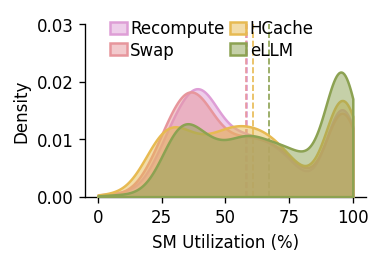

In [26]:
csv_files = [
    f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_3024_swap_4gpu.csv",
    f"{DATASET_PATH}/vllm-recompute/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_3024_recompute_4gpu.csv",
    f"{DATASET_PATH}/vllm-recompute/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_6069_recompute_4gpu.csv",
    f"{DATASET_PATH}/hcache/sharegpt/meta-llama_Llama-2-70b-chat-hf_gpu_monitor_3024_recompute_4gpu.csv",
]
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
# plot_metric_heatmap(csv_files, system_labels, 'sm', 'SM Utilization (%)')
plot_metric_density(csv_files, system_labels, 'sm', 'SM Utilization (%)')

In [27]:
# parse running requests in the log
from datetime import datetime
def extract_running_requests(log_file_path, output_csv_path):
    # 正则表达式匹配日志行中的时间和Running数量
    pattern = re.compile(
        r'INFO (\d{2}-\d{2} \d{2}:\d{2}:\d{2}).*Running: (\d+) reqs'
    )
    
    data = []
    
    with open(log_file_path, 'r') as file:
        for line in file:
            match = pattern.search(line)
            if match:
                # print(f"Found match: {match.group(0)}")
                timestamp_str = match.group(1)
                running_requests = int(match.group(2))

                current_year = datetime.now().year
                timestamp = datetime.strptime(
                    f"{current_year}-{timestamp_str}", 
                    "%Y-%m-%d %H:%M:%S"
                )
                
                data.append({
                    'timestamp': timestamp,
                    'running_requests': running_requests
                })
    
    data.sort(key=lambda x: x['timestamp'])
    print(f"Extracted {len(data)} entries.")
    
    with open(output_csv_path, 'w', newline='') as csvfile:
        fieldnames = ['timestamp', 'running_requests']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        writer.writeheader()
        for row in data:
            writer.writerow({
                'timestamp': row['timestamp'].strftime("%Y-%m-%d %H:%M:%S"),
                'running_requests': row['running_requests']
            })

In [28]:
input_log = f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_4541_swap_4gpu.log"  # 替换为你的输入日志文件名
# input_log = f"{DATASET_PATH}/vllm-recompute/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_recompute_4gpu.log"  # 替换为你的输入日志文件名
# input_log = f"{DATASET_PATH}/hcache/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_recompute_4gpu.log"  # 替换为你的输入日志文件名
# input_log = f"{DATASET_PATH}/ellm/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_recompute_4gpu.log"  # 替换为你的输入日志文件名
output_csv = input_log.replace('.log', '_running_requests.csv')  # 输出CSV文件名
# extract_running_requests(input_log, output_csv)

In [29]:
def plot_running_requests(csv_files, system_labels):
 
    fig = plt.figure(figsize=(3, 2), dpi=120)
    fig.patch.set_alpha(0.0)
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, csv_file in enumerate(csv_files):
        # 读取CSV文件
        df = pd.read_csv(csv_file)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
        sns.kdeplot(df['running_requests'], cumulative=False, color=plt.cm.tab20b((4-i)/4), linestyle='-', linewidth=1.5, label=system_labels[i], alpha=0.5, fill=True, zorder=10, cut=0)
        print(f"System {system_labels[i]}: Running requests mean value: {df['running_requests'].mean():.2f}")
        if i == 3:
            # 标记最大值
            max_value = df['running_requests'].max()
            max_index = df['running_requests'].idxmax()
            max_time = df['timestamp'].iloc[max_index]
            print(f"System {system_labels[i]}: Max running requests: {max_value} at {max_time}")
            ax.annotate(f'Max: {max_value}', xy=(max_value, 0.002), xytext=(max_value-80, 0.005),
                        arrowprops=dict(arrowstyle='->', lw=1.2),
                        fontsize=8, color=plt.cm.tab20b((4-i)/5))
        # 绘制均值线
        mean_value = df['running_requests'].mean()
        ax.axvline(mean_value, color=plt.cm.tab20b((4-i)/5), linestyle='--', linewidth=0.7, zorder=20)   
        print(f"System {system_labels[i]}: Running requests mean value: {mean_value:.2f}")
        
    ax.set_ylabel('Density')
    ax.set_xlabel('Running Requests')
    ax.set_ylim(0, 0.01)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.06, 0.75), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_running_requests.pdf', bbox_inches='tight')

System Recompute: Running requests mean value: 223.16
System Recompute: Running requests mean value: 223.16
System Swap: Running requests mean value: 220.94
System Swap: Running requests mean value: 220.94
System HCache: Running requests mean value: 240.71
System HCache: Running requests mean value: 240.71
System eLLM: Running requests mean value: 254.64
System eLLM: Max running requests: 448 at 2025-04-30 11:34:17
System eLLM: Running requests mean value: 254.64


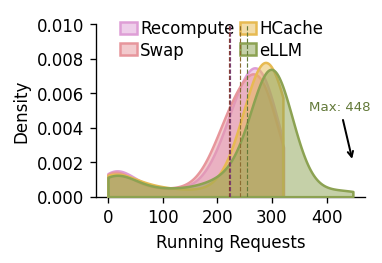

In [30]:
csv_files = [
    f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_swap_4gpu_running_requests.csv",
    f"{DATASET_PATH}/vllm-recompute/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_recompute_4gpu_running_requests.csv",
    f"{DATASET_PATH}/ellm/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_recompute_4gpu_running_requests.csv",
    f"{DATASET_PATH}/hcache/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_3024_recompute_4gpu_running_requests.csv",
    # f"{DATASET_PATH}/vllm-swap/sharegpt/meta-llama_Llama-2-70b-chat-hf_server_4541_swap_4gpu_running_requests.csv",
]
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
plot_running_requests(csv_files, system_labels)